In [ ]:
import sys
sys.path.append(".")
from src.sims import File_simulation, extract_usual_important_sim_data
from environment.environment_builder import EnvironmentBuilder
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Ellipse, Rectangle

# ── Style ────────────────────────────────────
plt.style.use('Volta.mplstyle')
prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']

# ─────────────────────────────────────────────
# SITE PARAMETERS — IREC 2026 MIDLAND TX
# Sources: DTEG §10.1.1, §11.1.2, §6.3.2
#          Contestant Solids Pad Operations Guide (pad layout map)
# ─────────────────────────────────────────────
RAIL_LENGTH_M   = 4.14    # 17 ft — DTEG §11.1.2
INCLINATION_DEG = 6.0     # 84° elevation = 6° from vertical — DTEG §10.1.1
HEADING_DEG     = 90.0    # East — pad orientation from layout map

# ─────────────────────────────────────────────
# ROCKET GEOMETRY
# ─────────────────────────────────────────────
ROCKET_LENGTH_M   = 3.23   # m
ROCKET_DIAMETER_M = 0.174  # m

# ─────────────────────────────────────────────
# IREC COMPLIANCE LIMITS — DTEG 2026
# ─────────────────────────────────────────────
MIN_RAIL_VEL_MS  = 25.0
STAB_MIN_CAL     = (7.5  / 100) * ROCKET_LENGTH_M / ROCKET_DIAMETER_M  # 1.392 cal
STAB_MAX_PAD_CAL = (18.0 / 100) * ROCKET_LENGTH_M / ROCKET_DIAMETER_M  # 3.341 cal
STAB_MAX_FLT_CAL = (25.0 / 100) * ROCKET_LENGTH_M / ROCKET_DIAMETER_M  # 4.641 cal

print("── IREC Compliance Limits ──────────────────────────")
print(f"  Min rail exit velocity   : {MIN_RAIL_VEL_MS:.1f} m/s")
print(f"  Min stability (subsonic) : {STAB_MIN_CAL:.3f} cal  (7.5% of length)")
print(f"  Max stability at launch  : {STAB_MAX_PAD_CAL:.3f} cal  (18% of length)")
print(f"  Max stability in flight  : {STAB_MAX_FLT_CAL:.3f} cal  (25% of length)")
print("────────────────────────────────────────────────────\n")

In [ ]:
# ═════════════════════════════════════════════
# CELL 2 — ENVIRONMENTS & SIMULATIONS  (slow)
# ═════════════════════════════════════════════
builder = EnvironmentBuilder()
envs, labels = builder.build_historical_environments(
    years=[2019, 2020, 2021, 2022, 2023, 2024],
    days=[15, 16, 17, 18, 19, 20],
    utc_hours=[12, 15, 18, 19, 20]
)

sim = File_simulation(
    "IREC_version_06(2)",
    "AeroTech_N3300R",
    cg_true=2.00,
    cp_true=2.48,
    mass_true=26.663
)

results        = {}
flight_objects = {}

for env, label in zip(envs, labels):
    sim.run_single_flight_sim(
        env=env,
        rail_length=RAIL_LENGTH_M,
        inclination=INCLINATION_DEG,
        heading=HEADING_DEG
    )
    results[label]        = extract_usual_important_sim_data(sim.single_flight_sim)
    flight_objects[label] = sim.single_flight_sim

df = pd.DataFrame(results)
print(df)
df.to_csv("resultadosIREC_V06.csv")
print("✓ resultadosIREC_V06.csv saved")

EnvironmentBuilder ready. Files found: [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]

Building 180 historical ERA5 environments...
  Years : [2019, 2020, 2021, 2022, 2023, 2024]
  Days  : [15, 16, 17, 18, 19, 20]
  Hours : [12, 15, 18, 19, 20] UTC

  [   1/180] ERA5_2019_0615_12Z OK
  [   2/180] ERA5_2019_0615_15Z OK
  [   3/180] ERA5_2019_0615_18Z OK
  [   4/180] ERA5_2019_0615_19Z OK
  [   5/180] ERA5_2019_0615_20Z OK
  [   6/180] ERA5_2019_0616_12Z OK
  [   7/180] ERA5_2019_0616_15Z OK
  [   8/180] ERA5_2019_0616_18Z OK


c:\Users\Luisa Fernanda\anaconda3\lib\site-packages\rocketpy\environment\tools.py:309: UserWarning: Exact chosen launch time is not available in the provided file, using 2019-06-15 15:00:00 UTC instead.
  warnings.warn(
c:\Users\Luisa Fernanda\anaconda3\lib\site-packages\rocketpy\environment\tools.py:309: UserWarning: Exact chosen launch time is not available in the provided file, using 2019-06-16 00:00:00 UTC instead.
  warnings.warn(
c:\Users\Luisa Fernanda\anaconda3\lib\site-packages\rocketpy\environment\tools.py:309: UserWarning: Exact chosen launch time is not available in the provided file, using 2019-06-16 18:00:00 UTC instead.
  warnings.warn(
c:\Users\Luisa Fernanda\anaconda3\lib\site-packages\rocketpy\environment\tools.py:309: UserWarning: Exact chosen launch time is not available in the provided file, using 2019-06-17 00:00:00 UTC instead.
  warnings.warn(


  [   9/180] ERA5_2019_0616_19Z OK
  [  10/180] ERA5_2019_0616_20Z OK
  [  11/180] ERA5_2019_0617_12Z OK
  [  12/180] ERA5_2019_0617_15Z OK
  [  13/180] ERA5_2019_0617_18Z OK
  [  14/180] ERA5_2019_0617_19Z OK
  [  15/180] ERA5_2019_0617_20Z OK
  [  16/180] ERA5_2019_0618_12Z OK


c:\Users\Luisa Fernanda\anaconda3\lib\site-packages\rocketpy\environment\tools.py:309: UserWarning: Exact chosen launch time is not available in the provided file, using 2019-06-17 18:00:00 UTC instead.
  warnings.warn(
c:\Users\Luisa Fernanda\anaconda3\lib\site-packages\rocketpy\environment\tools.py:309: UserWarning: Exact chosen launch time is not available in the provided file, using 2019-06-18 00:00:00 UTC instead.
  warnings.warn(
c:\Users\Luisa Fernanda\anaconda3\lib\site-packages\rocketpy\environment\tools.py:309: UserWarning: Exact chosen launch time is not available in the provided file, using 2019-06-18 18:00:00 UTC instead.
  warnings.warn(
c:\Users\Luisa Fernanda\anaconda3\lib\site-packages\rocketpy\environment\tools.py:309: UserWarning: Exact chosen launch time is not available in the provided file, using 2019-06-19 00:00:00 UTC instead.
  warnings.warn(


  [  17/180] ERA5_2019_0618_15Z OK
  [  18/180] ERA5_2019_0618_18Z OK
  [  19/180] ERA5_2019_0618_19Z OK
  [  20/180] ERA5_2019_0618_20Z OK
  [  21/180] ERA5_2019_0619_12Z OK
  [  22/180] ERA5_2019_0619_15Z OK
  [  23/180] ERA5_2019_0619_18Z OK
  [  24/180] ERA5_2019_0619_19Z OK
  [  25/180] ERA5_2019_0619_20Z OK
  [  26/180] ERA5_2019_0620_12Z OK


: 


── IREC Compliance Summary ─────────────────────────
  Total simulations  : 162
  PASS               : 162  (100.0%)
  FAIL               : 0  (0.0%)

  Rail velocity  failures : 0
  Stab min       failures : 0
  Stab pad max   failures : 0
  Stab flt max   failures : 0
────────────────────────────────────────────────────


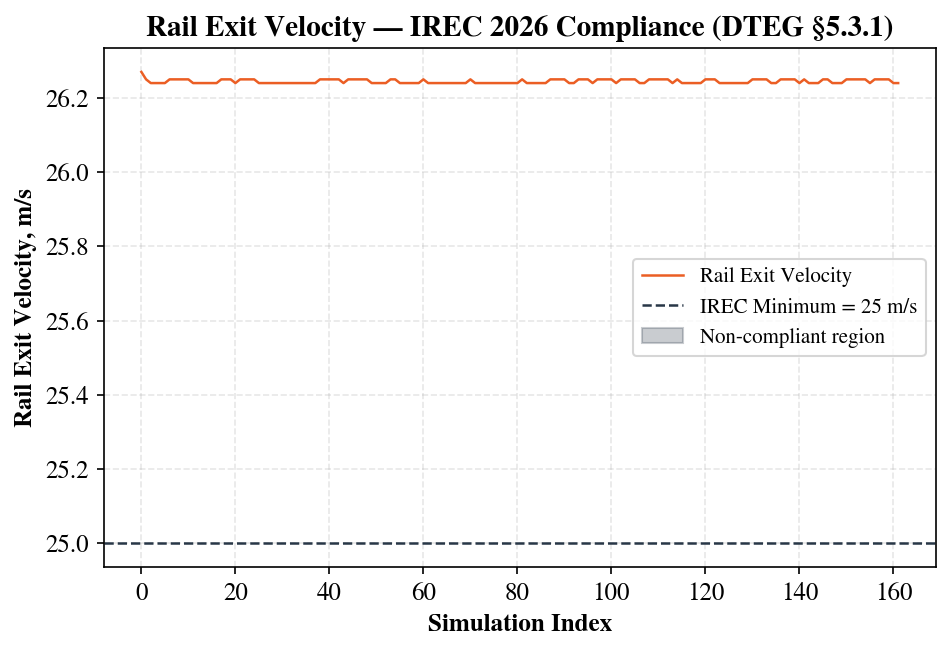

✓ compliance_rail_vel.png saved


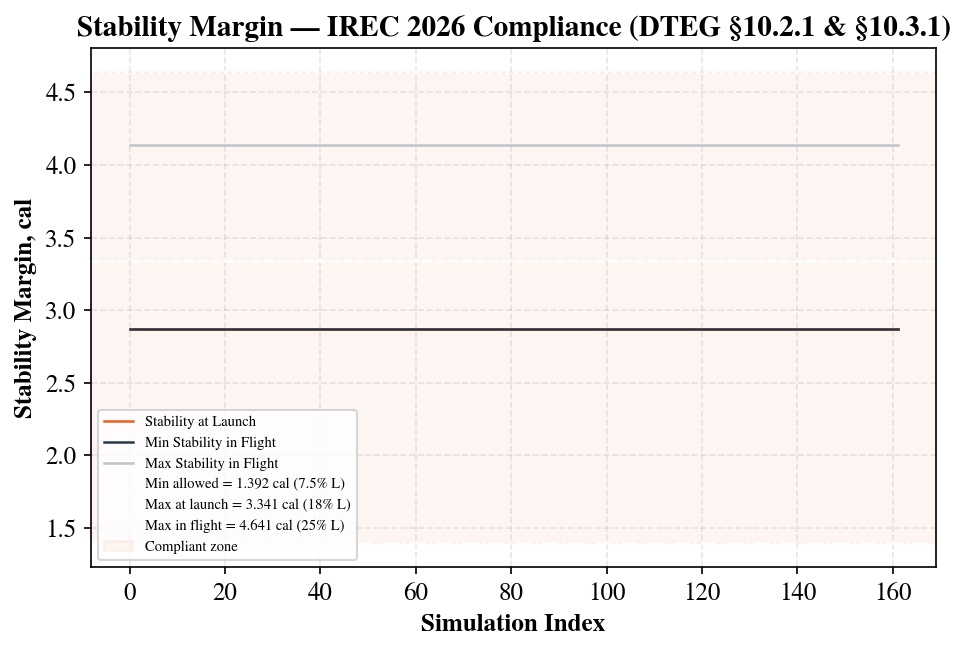

✓ compliance_stability.png saved


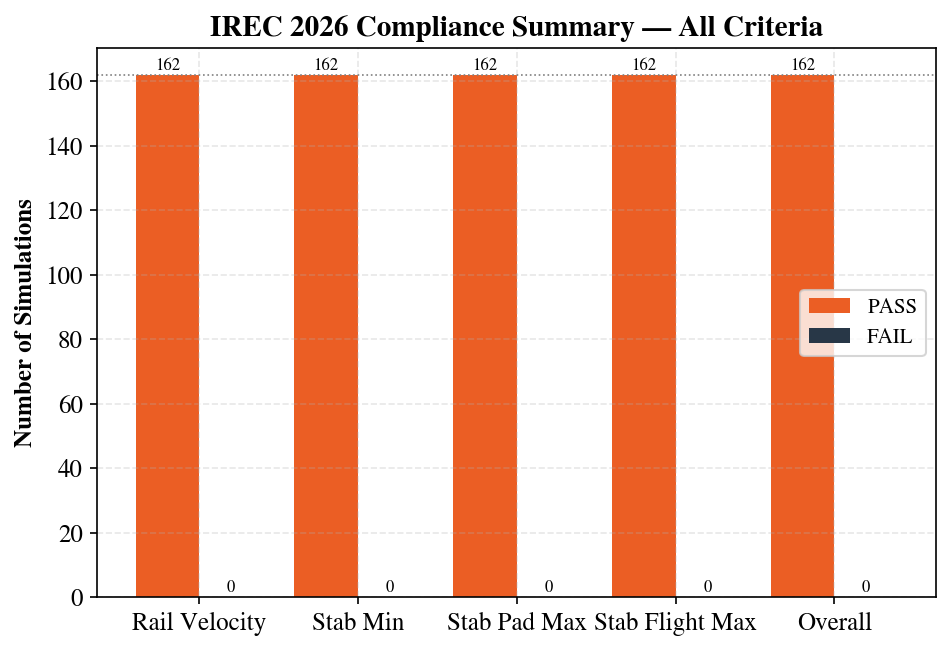

✓ compliance_summary.png saved


In [ ]:
# ═════════════════════════════════════════════
# CELL 3 — IREC COMPLIANCE VERIFICATION
# ═════════════════════════════════════════════
compliance = []

for lbl, flight in flight_objects.items():
        v_rail    = flight.out_of_rail_velocity
        ok_rail   = v_rail >= MIN_RAIL_VEL_MS

        stab_init = flight.initial_stability_margin
        stab_rail = flight.out_of_rail_stability_margin
        stab_max  = flight.max_stability_margin
        stab_min  = flight.min_stability_margin

        ok_stab_min     = stab_min  >= STAB_MIN_CAL
        ok_stab_pad_max = stab_init <= STAB_MAX_PAD_CAL
        ok_stab_flt_max = stab_max  <= STAB_MAX_FLT_CAL
        ok_all = ok_rail and ok_stab_min and ok_stab_pad_max and ok_stab_flt_max

        compliance.append({
        "label":            lbl,
        "rail_vel [m/s]":   round(v_rail,    2),
        "rail_vel OK":      ok_rail,
        "stab_init [cal]":  round(stab_init, 3),
        "stab_min [cal]":   round(stab_min,  3),
        "stab_max [cal]":   round(stab_max,  3),
        "stab_min OK":      ok_stab_min,
        "stab_pad_max OK":  ok_stab_pad_max,
        "stab_flt_max OK":  ok_stab_flt_max,
        "PASS":             ok_all,
})

df_comp = pd.DataFrame(compliance)
df_comp.to_csv("compliance_IREC_V06.csv", index=False)

n_total = len(df_comp)
n_pass  = df_comp["PASS"].sum()
n_fail  = n_total - n_pass

print("\n── IREC Compliance Summary ─────────────────────────")
print(f"  Total simulations  : {n_total}")
print(f"  PASS               : {n_pass}  ({100*n_pass/n_total:.1f}%)")
print(f"  FAIL               : {n_fail}  ({100*n_fail/n_total:.1f}%)")
print(f"\n  Rail velocity  failures : {(~df_comp['rail_vel OK']).sum()}")
print(f"  Stab min       failures : {(~df_comp['stab_min OK']).sum()}")
print(f"  Stab pad max   failures : {(~df_comp['stab_pad_max OK']).sum()}")
print(f"  Stab flt max   failures : {(~df_comp['stab_flt_max OK']).sum()}")
print("────────────────────────────────────────────────────")

# ── Plot 1: Rail exit velocity ────────────────
fig, ax = plt.subplots()
ax.plot(range(n_total), df_comp["rail_vel [m/s]"],
        color=colors[0], linewidth=1.2, label='Rail Exit Velocity')
ax.axhline(MIN_RAIL_VEL_MS, color=colors[1], linestyle='--', linewidth=1.2,
        label=f'IREC Minimum = {MIN_RAIL_VEL_MS:.0f} m/s')
ax.fill_between(range(n_total), df_comp["rail_vel [m/s]"], MIN_RAIL_VEL_MS,
                where=df_comp["rail_vel [m/s]"] < MIN_RAIL_VEL_MS,
                color=colors[1], alpha=0.25, label='Non-compliant region')
ax.set_xlabel('Simulation Index')
ax.set_ylabel('Rail Exit Velocity, m/s')
ax.set_title('Rail Exit Velocity — IREC 2026 Compliance (DTEG §5.3.1)')
ax.legend()
plt.tight_layout()
plt.savefig("compliance_rail_vel.png", dpi=150)
plt.show()
print("✓ compliance_rail_vel.png saved")

# ── Plot 2: Stability margin ──────────────────

n_colors = len(colors)  # cuántos tiene tu Volta.mplstyle

fig, ax = plt.subplots()
ax.plot(range(n_total), df_comp["stab_init [cal]"],
        color=colors[0 % n_colors], linewidth=1.2, label='Stability at Launch')
ax.plot(range(n_total), df_comp["stab_min [cal]"],
        color=colors[1 % n_colors], linewidth=1.2, label='Min Stability in Flight')
ax.plot(range(n_total), df_comp["stab_max [cal]"],
        color=colors[2 % n_colors], linewidth=1.2, label='Max Stability in Flight')

# Límites — todos en gris pero con distinto estilo de línea
ax.axhline(STAB_MIN_CAL,     color='white', linestyle='-.',  linewidth=1.2,
        label=f'Min allowed = {STAB_MIN_CAL:.3f} cal (7.5% L)')
ax.axhline(STAB_MAX_PAD_CAL, color='white', linestyle='--',  linewidth=1.2,
        label=f'Max at launch = {STAB_MAX_PAD_CAL:.3f} cal (18% L)')
ax.axhline(STAB_MAX_FLT_CAL, color='white', linestyle=':',   linewidth=1.5,
        label=f'Max in flight = {STAB_MAX_FLT_CAL:.3f} cal (25% L)')

ax.axhspan(STAB_MIN_CAL, STAB_MAX_FLT_CAL, alpha=0.06,
        color=colors[0 % n_colors], label='Compliant zone')
ax.set_xlabel('Simulation Index')
ax.set_ylabel('Stability Margin, cal')
ax.set_title('Stability Margin — IREC 2026 Compliance (DTEG §10.2.1 & §10.3.1)')
ax.legend(fontsize=7)
plt.tight_layout()
plt.savefig("compliance_stability.png", dpi=150)
plt.show()
print("✓ compliance_stability.png saved")

# ── Plot 3: PASS/FAIL summary ─────────────────
criteria    = ['Rail Velocity', 'Stab Min', 'Stab Pad Max', 'Stab Flight Max', 'Overall']
pass_counts = [df_comp['rail_vel OK'].sum(), df_comp['stab_min OK'].sum(),
        df_comp['stab_pad_max OK'].sum(), df_comp['stab_flt_max OK'].sum(),
        df_comp['PASS'].sum()]
fail_counts = [n_total - p for p in pass_counts]
x     = np.arange(len(criteria))
width = 0.4

fig, ax = plt.subplots()
bars_pass = ax.bar(x - width/2, pass_counts, width, label='PASS', color=colors[0])
bars_fail = ax.bar(x + width/2, fail_counts, width, label='FAIL', color=colors[1])
ax.set_xticks(x)
ax.set_xticklabels(criteria)
ax.set_ylabel('Number of Simulations')
ax.set_title('IREC 2026 Compliance Summary — All Criteria')
ax.legend()
ax.axhline(n_total, color='gray', linestyle=':', linewidth=0.8)
for bar in list(bars_pass) + list(bars_fail):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                str(int(bar.get_height())), ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig("compliance_summary.png", dpi=150)
plt.show()
print("✓ compliance_summary.png saved")

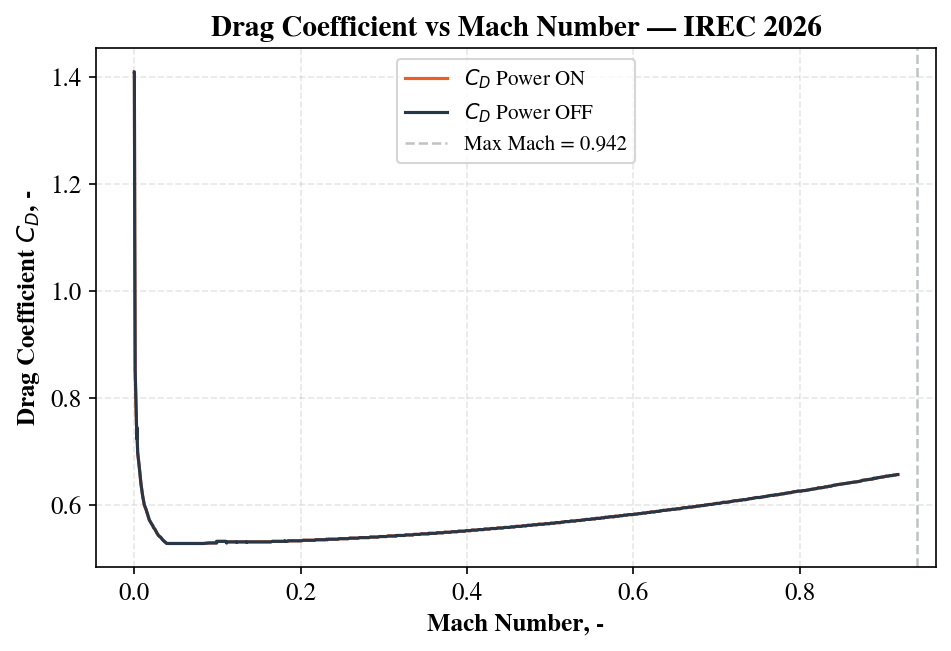

✓ cd_vs_mach.png saved


In [20]:
# ═════════════════════════════════════════════
# CELL 4 — Cd VS MACH
# ═════════════════════════════════════════════
cd_on  = sim.rocket.power_on_drag.source
cd_off = sim.rocket.power_off_drag.source

df_cd_mach = pd.DataFrame({
    "Mach":         cd_on[:, 0],
    "Cd_power_on":  cd_on[:, 1],
    "Cd_power_off": cd_off[:, 1],
})
df_cd_mach.to_csv("cd_vs_machIREC_V06.csv", index=False)

mach_max_global = max(results[lbl]["max_mach [-]"] for lbl in results)

fig, ax = plt.subplots()
ax.plot(cd_on[:, 0],  cd_on[:, 1],  color=colors[0], linewidth=1.5, label='$C_D$ Power ON')
ax.plot(cd_off[:, 0], cd_off[:, 1], color=colors[1], linewidth=1.5, label='$C_D$ Power OFF')
ax.axvline(mach_max_global, color=colors[2], linestyle='--', linewidth=1.2,
        label=f'Max Mach = {mach_max_global:.3f}')
ax.set_xlabel('Mach Number, -')
ax.set_ylabel('Drag Coefficient $C_D$, -')
ax.set_title('Drag Coefficient vs Mach Number — IREC 2026')
ax.legend()
plt.tight_layout()
plt.savefig("cd_vs_mach.png", dpi=150)
plt.show()
print("✓ cd_vs_mach.png saved")


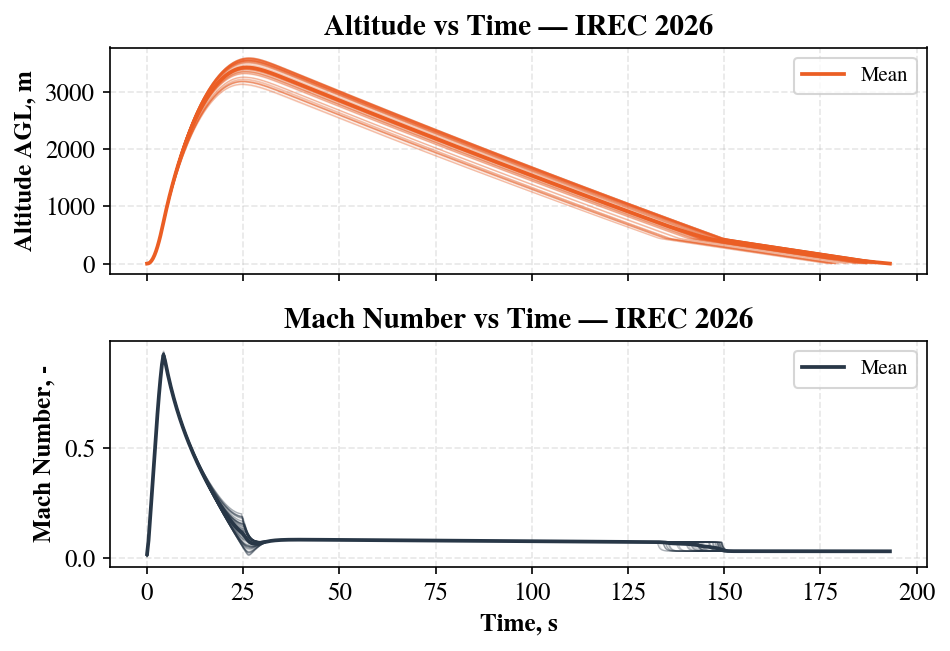

✓ altitude_mach_vs_time.png saved


In [21]:
# ═════════════════════════════════════════════
# CELL 5 — ALTITUDE & MACH VS TIME
# ═════════════════════════════════════════════
alt_all, mach_all = [], []

for label, flight in flight_objects.items():
    t    = flight.time
    alt  = np.array([flight.altitude(ti)    for ti in t])
    mach = np.array([flight.mach_number(ti) for ti in t])
    alt_all.append((t, alt))
    mach_all.append((t, mach))

t_ref = np.linspace(0, max(t[-1] for t, _ in alt_all), 500)
alt_interp, mach_interp = [], []
for (t_a, alt), (t_m, mach) in zip(alt_all, mach_all):
    alt_interp.append( np.interp(t_ref, t_a, alt,  left=np.nan, right=np.nan))
    mach_interp.append(np.interp(t_ref, t_m, mach, left=np.nan, right=np.nan))

alt_mean  = np.nanmean(np.array(alt_interp),  axis=0)
mach_mean = np.nanmean(np.array(mach_interp), axis=0)

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
for t_a, alt in alt_all:
    ax1.plot(t_a, alt, color=colors[0], alpha=0.10, linewidth=0.6)
ax1.plot(t_ref, alt_mean, color=colors[0], linewidth=1.8, label='Mean')
ax1.set_ylabel('Altitude AGL, m')
ax1.set_title('Altitude vs Time — IREC 2026')
ax1.legend()

for t_m, mach in mach_all:
    ax2.plot(t_m, mach, color=colors[1], alpha=0.10, linewidth=0.6)
ax2.plot(t_ref, mach_mean, color=colors[1], linewidth=1.8, label='Mean')
ax2.set_xlabel('Time, s')
ax2.set_ylabel('Mach Number, -')
ax2.set_title('Mach Number vs Time — IREC 2026')
ax2.legend()

plt.tight_layout()
plt.savefig("altitude_mach_vs_time.png", dpi=150)
plt.show()
print("✓ altitude_mach_vs_time.png saved")

r_max : 1970.6 m
r_95  : 1888.0 m
r_68  : 1262.1 m
LCO/RSO position  : (-976.4 m E,  -1078.9 m N)
Distance pad→spec : 1455.1 m


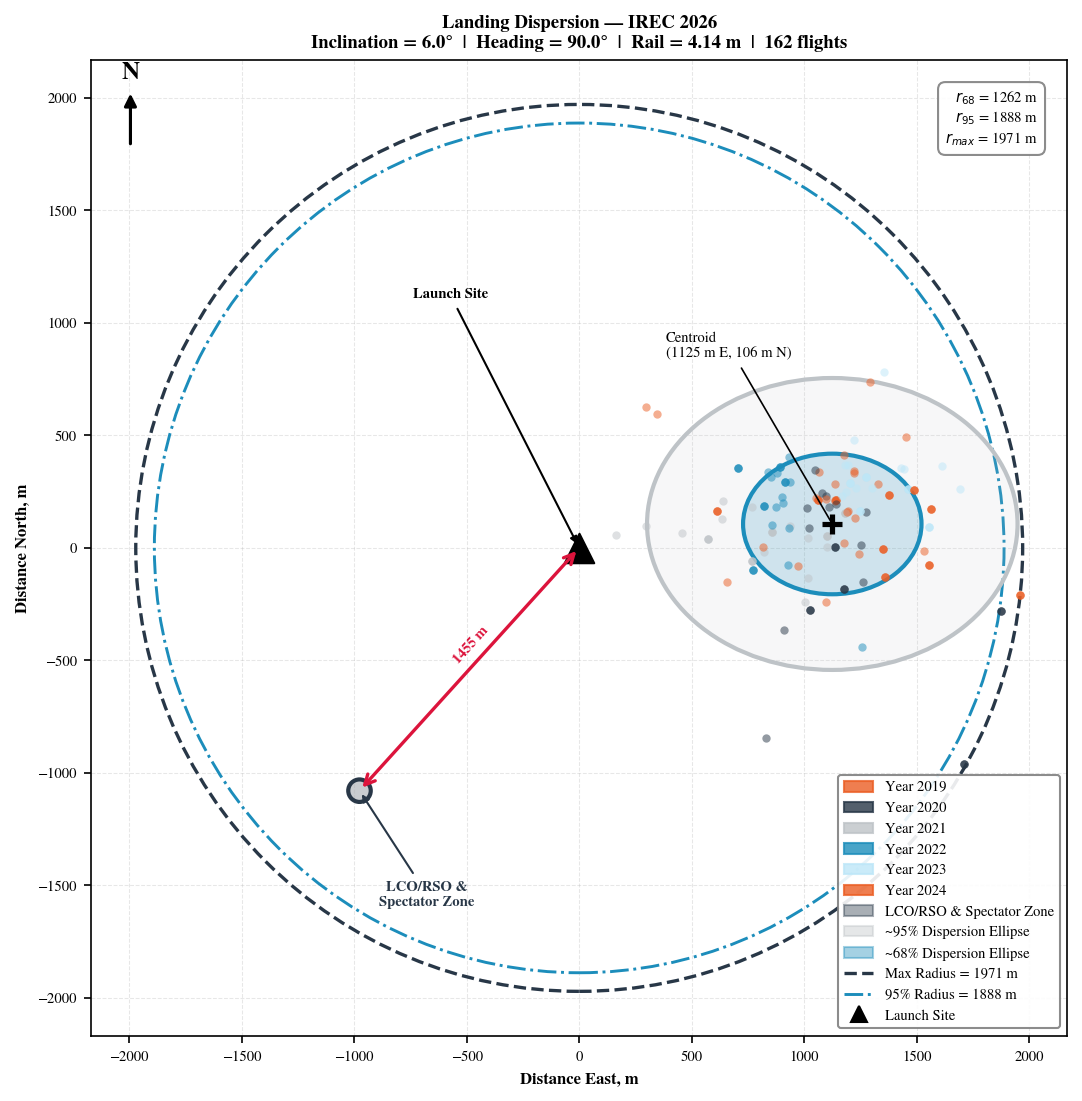

In [22]:
# ═════════════════════════════════════════════
# CELL 6 — LANDING DISPERSION MAP
# ═════════════════════════════════════════════

from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# ── 1. Extraer datos de landing ──────────────────────────
x_land    = np.array([results[label]['impact_x [m]']      for label in labels])
y_land    = np.array([results[label]['impact_y [m]']      for label in labels])
distances = np.array([results[label]['impact_radius [m]'] for label in labels])

# ── 2. Radios de dispersión ──────────────────────────────
r_max = distances.max()
r_95  = np.percentile(distances, 95)
r_68  = np.percentile(distances, 68)

print(f"r_max : {r_max:.1f} m")
print(f"r_95  : {r_95:.1f} m")
print(f"r_68  : {r_68:.1f} m")

# ── 3. Centroide y desviaciones ──────────────────────────
cx    = x_land.mean()
cy    = y_land.mean()
std_x = x_land.std()
std_y = y_land.std()

# ── 4. Coordenadas relativas al centroide ────────────────
dx = x_land - cx
dy = y_land - cy

# ── 5. Setup de colores con Volta style ──────────────────
prop_cycle   = plt.rcParams['axes.prop_cycle']
colors       = prop_cycle.by_key()['color']
n_c          = len(colors)

# ── 6. Años únicos y color_map ───────────────────────────
years_unique = sorted(set(int(label.split('_')[1]) for label in labels))
color_map    = {str(yr): colors[i % n_c] for i, yr in enumerate(years_unique)}

# ── 7. Colores para zonas y círculos ─────────────────────
COL_RMAX = '#283747'
COL_R95  = '#1C8DBB'
COL_SPEC = colors[(len(years_unique) + 0) % n_c]
COL_E95  = colors[(len(years_unique) + 1) % n_c]
COL_E68  = colors[(len(years_unique) + 2) % n_c]

# ── 8. Tamaños de fuente ─────────────────────────────────
FS_TITLE  = 9
FS_LABEL  = 8
FS_TICK   = 7
FS_ANNOT  = 7
FS_LEGEND = 7
FS_STATS  = 7

# ─────────────────────────────────────────────────────────
# LCO/RSO & SPECTATOR ZONE — IREC 2026 Site Map (ESRA)
# Solids Pad  : 31.047292°N, 103.527281°W  → origin (0, 0)
# LCO/RSO     : 31.037589°N, 103.537530°W
# Projection  : equirectangular local (R=6371000 m)
# ─────────────────────────────────────────────────────────
_R       = 6371000.0
_LAT0    = 31.047292
_LON0    = -103.527281
_LAT_S   = 31.037589
_LON_S   = -103.537530
SPEC_CX  = (_LON_S - _LON0) * np.pi/180 * _R * np.cos(_LAT0 * np.pi/180)  # +976.4 m E
SPEC_CY  = (_LAT_S - _LAT0) * np.pi/180 * _R                               # -1078.9 m N
SPEC_R   = 50.0   # radio visual del marcador, m (ajustable)
DIST_PAD_SPEC = np.sqrt(SPEC_CX**2 + SPEC_CY**2)  # 1455.1 m

print(f"LCO/RSO position  : ({SPEC_CX:.1f} m E,  {SPEC_CY:.1f} m N)")
print(f"Distance pad→spec : {DIST_PAD_SPEC:.1f} m")

# ══════════════════════════════════════════════════════════
# FIGURA PRINCIPAL
# ══════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(8, 7.5))

# ── LCO/RSO & Spectator Zone ──────────────────────────────
ax.add_patch(plt.Circle((SPEC_CX, SPEC_CY), SPEC_R,
    edgecolor=COL_SPEC, facecolor=COL_SPEC, alpha=0.25, zorder=1))
ax.add_patch(plt.Circle((SPEC_CX, SPEC_CY), SPEC_R,
    edgecolor=COL_SPEC, facecolor="none", linewidth=2, zorder=2))
ax.annotate(
    f"LCO/RSO &\nSpectator Zone",
    xy=(SPEC_CX, SPEC_CY),
    xytext=(SPEC_CX + 300, SPEC_CY - 400),   # ← derecha y abajo
    ha="center", va="top", fontsize=FS_ANNOT, fontweight="bold", color=COL_SPEC, zorder=10,
    arrowprops=dict(arrowstyle="-|>", color=COL_SPEC, lw=1.0))

# ── Radius circles from pad ───────────────────────────────
ax.add_patch(plt.Circle((0,0), r_max, edgecolor=COL_RMAX, facecolor="none",
    linestyle="--", linewidth=1.6, zorder=3))
ax.add_patch(plt.Circle((0,0), r_95, edgecolor=COL_R95, facecolor="none",
    linestyle="-.", linewidth=1.4, zorder=3))

# ── Dispersion ellipses (centered on centroid) ────────────
ax.add_patch(Ellipse(xy=(cx,cy), width=2*2.45*std_x, height=2*2.45*std_y,
    edgecolor=COL_E95, facecolor=COL_E95, alpha=0.12, linewidth=0, zorder=4))
ax.add_patch(Ellipse(xy=(cx,cy), width=2*2.45*std_x, height=2*2.45*std_y,
    edgecolor=COL_E95, facecolor="none", linewidth=2.0, zorder=4))
ax.add_patch(Ellipse(xy=(cx,cy), width=2*1.18*std_x, height=2*1.18*std_y,
    edgecolor=COL_E68, facecolor=COL_E68, alpha=0.18, linewidth=0, zorder=5))
ax.add_patch(Ellipse(xy=(cx,cy), width=2*1.18*std_x, height=2*1.18*std_y,
    edgecolor=COL_E68, facecolor="none", linewidth=2.0, zorder=5))

# ── Landing points ────────────────────────────────────────
for xi, yi, lbl in zip(x_land, y_land, labels):
    yr = lbl.split("_")[1]
    ax.scatter(xi, yi, color=color_map[yr], s=16, alpha=0.50, zorder=6, linewidths=0)

# ── Launch site ───────────────────────────────────────────
ax.scatter(0, 0, color="black", s=200, marker="^", zorder=11)
ax.annotate("Launch Site", xy=(0,0), xytext=(-80, 120),
    textcoords="offset points", fontsize=FS_ANNOT, fontweight="bold",
    arrowprops=dict(arrowstyle="-|>", color="black", lw=1.0), zorder=12)

# ── Centroid ──────────────────────────────────────────────
ax.scatter(cx, cy, color="black", s=90, marker="+", zorder=12, linewidths=2.5)
ax.annotate(f"Centroid\n({cx:.0f} m E, {cy:.0f} m N)",
    xy=(cx,cy), xytext=(-80, 80), textcoords="offset points", fontsize=FS_ANNOT,
    arrowprops=dict(arrowstyle="-", color="black", lw=0.8), zorder=12)

# ── Stats box ─────────────────────────────────────────────
ax.annotate(
    f"$r_{{68}}$ = {r_68:.0f} m\n$r_{{95}}$ = {r_95:.0f} m\n$r_{{max}}$ = {r_max:.0f} m",
    xy=(0.97, 0.97), xycoords="axes fraction", ha="right", va="top", fontsize=FS_STATS,
    bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="gray", alpha=0.9),
    zorder=13)

# ── North arrow ───────────────────────────────────────────
ax.annotate("", xy=(0.04, 0.97), xytext=(0.04, 0.91), xycoords="axes fraction",
    arrowprops=dict(arrowstyle="-|>", color="black", lw=1.5), zorder=13)
ax.text(0.04, 0.975, "N", transform=ax.transAxes,
    ha="center", va="bottom", fontsize=12, fontweight="bold", zorder=13)

# ── Legend ────────────────────────────────────────────────
legend_yr = [mpatches.Patch(color=color_map[str(yr)], label=f"Year {yr}", alpha=0.8)
             for yr in years_unique]
legend_extra = [
    mpatches.Patch(color=COL_SPEC, alpha=0.4,  label="LCO/RSO & Spectator Zone"),
    mpatches.Patch(color=COL_E95,  alpha=0.4,  label="~95% Dispersion Ellipse"),
    mpatches.Patch(color=COL_E68,  alpha=0.4,  label="~68% Dispersion Ellipse"),
    plt.Line2D([0],[0], color=COL_RMAX, linestyle="--", linewidth=1.6,
               label=f"Max Radius = {r_max:.0f} m"),
    plt.Line2D([0],[0], color=COL_R95,  linestyle="-.", linewidth=1.4,
               label=f"95% Radius = {r_95:.0f} m"),
    plt.Line2D([0],[0], color="black", marker="^", linestyle="None",
               markersize=8, label="Launch Site"),
]
ax.legend(handles=legend_yr + legend_extra, loc="lower right", fontsize=FS_LEGEND,
          framealpha=0.9, edgecolor="gray")

# ── Axes ──────────────────────────────────────────────────
ax.set_xlabel("Distance East, m", fontsize=FS_LABEL)
ax.set_ylabel("Distance North, m", fontsize=FS_LABEL)
ax.tick_params(labelsize=FS_TICK)
ax.set_title(
    f"Landing Dispersion — IREC 2026\n"
    f"Inclination = {INCLINATION_DEG}°  |  Heading = {HEADING_DEG}°  |  "
    f"Rail = {RAIL_LENGTH_M} m  |  {len(labels)} flights",
    fontsize=FS_TITLE, fontweight="bold")
ax.set_aspect("equal")
ax.grid(True, alpha=0.3, linewidth=0.5)

# ── Flecha pad ↔ LCO/RSO con distancia ───────────────────
ax.annotate("", xy=(SPEC_CX, SPEC_CY), xytext=(0, 0),
    arrowprops=dict(arrowstyle="<->", color="crimson", lw=1.6), zorder=13)
angle = np.degrees(np.arctan2(SPEC_CY, SPEC_CX))
if angle < -90 or angle > 90:
    angle += 180   # ← voltea el texto para que sea legible

ax.text(SPEC_CX / 2, SPEC_CY / 2,
        f" {DIST_PAD_SPEC:.0f} m", ha="center", va="bottom",
        fontsize=FS_ANNOT, color="crimson", fontweight="bold",
        rotation=angle, zorder=14)

plt.tight_layout()
plt.savefig("landing_dispersion.png", dpi=150, bbox_inches="tight")
plt.show()



In [7]:
print(labels[:3])

['ERA5_2019_0615_12Z', 'ERA5_2019_0615_15Z', 'ERA5_2019_0615_18Z']


In [9]:
print(results[labels[0]].keys())

dict_keys(['initial_static_margin [calibers]', 'frontal_surface_wind [m/s]', 'lateral_surface_wind [m/s]', 'out_rail_vel [m/s]', 'out_rail_stability [calibers]', 'out_rail_angle_of_attack [deg]', 'out_rail_thrust_to_weight [ratio]', 'burn_out_dynamic_pressure [Pa]', 'burn_out_time [s]', 'burn_out_accel [m/s²]', 'apogee_alt [m]', 'apogee_time [s]', 'max_speed [m/s]', 'max_speed_time [s]', 'max_mach [-]', 'max_mach_time [s]', 'max_dynamic_pressure [Pa]', 'max_dynamic_pressure_time [s]', 'max_acceleration_power_on [m/s²]', 'max_acceleration_power_on_time [s]', 'max_Gs_power_on [G]', 'max_Gs_power_on_time [s]', 'max_acceleration_power_off [m/s²]', 'max_acceleration_power_off_time [s]', 'max_Gs_power_off [G]', 'max_Gs_power_off_time [s]', 'max_stability_margin [calibers]', 'impact_speed [m/s]', 'impact_time [s]', 'impact_x [m]', 'impact_y [m]', 'impact_lat [°]', 'impact_lon [°]', 'impact_radius [m]'])


In [23]:
df = pd.read_csv("resultadosIREC_V06.csv", index_col=0)

print("SHAPE:", df.shape)
print("\nINDEX (filas):", df.index.tolist())
print("\nCOLUMNS (primeras 5):", df.columns.tolist()[:5])
print("\nPrimeras filas:")
print(df.head())

SHAPE: (34, 162)

INDEX (filas): ['initial_static_margin [calibers]', 'frontal_surface_wind [m/s]', 'lateral_surface_wind [m/s]', 'out_rail_vel [m/s]', 'out_rail_stability [calibers]', 'out_rail_angle_of_attack [deg]', 'out_rail_thrust_to_weight [ratio]', 'burn_out_dynamic_pressure [Pa]', 'burn_out_time [s]', 'burn_out_accel [m/s²]', 'apogee_alt [m]', 'apogee_time [s]', 'max_speed [m/s]', 'max_speed_time [s]', 'max_mach [-]', 'max_mach_time [s]', 'max_dynamic_pressure [Pa]', 'max_dynamic_pressure_time [s]', 'max_acceleration_power_on [m/s²]', 'max_acceleration_power_on_time [s]', 'max_Gs_power_on [G]', 'max_Gs_power_on_time [s]', 'max_acceleration_power_off [m/s²]', 'max_acceleration_power_off_time [s]', 'max_Gs_power_off [G]', 'max_Gs_power_off_time [s]', 'max_stability_margin [calibers]', 'impact_speed [m/s]', 'impact_time [s]', 'impact_x [m]', 'impact_y [m]', 'impact_lat [°]', 'impact_lon [°]', 'impact_radius [m]']

COLUMNS (primeras 5): ['ERA5_2019_0615_12Z', 'ERA5_2019_0615_15Z', 

In [24]:
# ── Apogee stats ──────────────────────────────────────────────
apogee_ft = df.loc["apogee_alt [m]"] * 3.28084
mean_apogee = apogee_ft.mean()
min_apogee  = apogee_ft.min()
max_apogee  = apogee_ft.max()

print(f"Mean apogee : {mean_apogee:,.0f} ft")
print(f"Min  apogee : {min_apogee:,.0f} ft")
print(f"Max  apogee : {max_apogee:,.0f} ft")

# ── Off-rail stability margin ──────────────────────────────────
stab = df.loc["out_rail_stability [calibers]"]
print(f"\nOff-rail stability — mean: {stab.mean():.2f} cal | min: {stab.min():.2f} cal | max: {stab.max():.2f} cal")

# ── Thrust-to-weight ratio ─────────────────────────────────────
twr = df.loc["out_rail_thrust_to_weight [ratio]"]
print(f"Thrust-to-weight  — mean: {twr.mean():.2f}     | min: {twr.min():.2f}     | max: {twr.max():.2f}")

Mean apogee : 11,255 ft
Min  apogee : 10,251 ft
Max  apogee : 11,809 ft

Off-rail stability — mean: 2.94 cal | min: 2.94 cal | max: 2.94 cal
Thrust-to-weight  — mean: 9.60     | min: 9.60     | max: 9.60


# CASOS LIMITES ----------------------------------------------------

In [8]:
import sys
sys.path.append(".")
from src.sims import File_simulation, extract_usual_important_sim_data
from environment.environment_builder import EnvironmentBuilder
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Ellipse, Rectangle

# ── Style ────────────────────────────────────
plt.style.use('Volta.mplstyle')
prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']

# ─────────────────────────────────────────────
# SITE PARAMETERS — IREC 2026 MIDLAND TX
# Sources: DTEG §10.1.1, §11.1.2, §6.3.2
# ─────────────────────────────────────────────
RAIL_LENGTH_M   = 5.2
INCLINATION_DEG = 6.0    # nominal
HEADING_DEG     = 90.0   # nominal

# ─────────────────────────────────────────────
# ROCKET GEOMETRY
# ─────────────────────────────────────────────
ROCKET_LENGTH_M   = 3.23
ROCKET_DIAMETER_M = 0.174

# ─────────────────────────────────────────────
# IREC COMPLIANCE LIMITS — DTEG 2026
# ─────────────────────────────────────────────
MIN_RAIL_VEL_MS  = 25.0
STAB_MIN_CAL     = (7.5  / 100) * ROCKET_LENGTH_M / ROCKET_DIAMETER_M
STAB_MAX_PAD_CAL = (18.0 / 100) * ROCKET_LENGTH_M / ROCKET_DIAMETER_M
STAB_MAX_FLT_CAL = (25.0 / 100) * ROCKET_LENGTH_M / ROCKET_DIAMETER_M

print("── IREC Compliance Limits ──────────────────────────")
print(f"  Min rail exit velocity   : {MIN_RAIL_VEL_MS:.1f} m/s")
print(f"  Min stability (subsonic) : {STAB_MIN_CAL:.3f} cal  (7.5% of length)")
print(f"  Max stability at launch  : {STAB_MAX_PAD_CAL:.3f} cal  (18% of length)")
print(f"  Max stability in flight  : {STAB_MAX_FLT_CAL:.3f} cal  (25% of length)")
print("────────────────────────────────────────────────────\n")

# ─────────────────────────────────────────────
# CASOS LÍMITE — DTEG §10.1.1
# ─────────────────────────────────────────────
INCLINATION_CASES = {
    "min_elev_82deg": 8.0,   # 82° elevación = 8° desde vertical
    "nom_elev_84deg": 6.0,   # 84° elevación = 6° desde vertical
    "max_elev_86deg": 4.0,   # 86° elevación = 4° desde vertical
}

HEADING_CASES = {
    "North": 0.0,
    "East":  90.0,
    "South": 180.0,
    "West":  270.0,
}

# ─────────────────────────────────────────────
# SPECTATOR/PARKING ZONE GEOMETRY
# ─────────────────────────────────────────────
GRID_M       = 6.1
SPEC_X_NEAR  = -2  * GRID_M
SPEC_X_FAR   = -8  * GRID_M
SPEC_Y_HALF  =  4.5 * GRID_M
SPEC_WIDTH   = abs(SPEC_X_FAR - SPEC_X_NEAR)
SPEC_HEIGHT  = 2 * SPEC_Y_HALF

── IREC Compliance Limits ──────────────────────────
  Min rail exit velocity   : 25.0 m/s
  Min stability (subsonic) : 1.392 cal  (7.5% of length)
  Max stability at launch  : 3.341 cal  (18% of length)
  Max stability in flight  : 4.641 cal  (25% of length)
────────────────────────────────────────────────────



In [5]:
# ═════════════════════════════════════════════
# CELL 2 — ENVIRONMENTS & LIMIT CASE SIMULATIONS
# ═════════════════════════════════════════════
builder = EnvironmentBuilder()
envs, labels = builder.build_historical_environments(
    years=[2022, 2023, 2024],
    days=[16, 19],
    utc_hours=[15, 18]
)

sim = File_simulation(
    "IREC_version04",
    "AeroTech_N3300R",
    cg_true=2.01,
    cp_true=2.54,
    mass_true=24.192
)

results        = {}
flight_objects = {}

for incl_name, incl_val in INCLINATION_CASES.items():
    for head_name, head_val in HEADING_CASES.items():
        case_key = f"{incl_name}__{head_name}"
        for env, env_label in zip(envs, labels):
            full_label = f"{case_key}__{env_label}"
            sim.run_single_flight_sim(
                env=env,
                rail_length=RAIL_LENGTH_M,
                inclination=incl_val,
                heading=head_val
            )
            results[full_label]                    = extract_usual_important_sim_data(sim.single_flight_sim)
            results[full_label]["inclination_deg"] = 90 - incl_val
            results[full_label]["heading_deg"]     = head_val
            results[full_label]["case_key"]        = case_key
            flight_objects[full_label]             = sim.single_flight_sim

# Al final del loop de simulaciones — Cell 2
labels_full = list(flight_objects.keys())

df = pd.DataFrame(results).T
df.to_csv("resultados_limit_cases.csv")
print(f"✓ {len(results)} simulaciones completadas")
print("✓ resultados_limit_cases.csv saved")


EnvironmentBuilder ready. Files found: [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]

Building 12 historical ERA5 environments...
  Years : [2022, 2023, 2024]
  Days  : [16, 19]
  Hours : [15, 18] UTC

  [   1/12] ERA5_2022_0616_15Z SKIPPED (Longitude -103.5473133 not inside region covered by file, which is from -103.0 to -101.5.)
  [   2/12] ERA5_2022_0616_18Z SKIPPED (Longitude -103.5473133 not inside region covered by file, which is from -103.0 to -101.5.)
  [   3/12] ERA5_2022_0619_15Z SKIPPED (Longitude -103.5473133 not inside region covered by file, which is from -103.0 to -101.5.)
  [   4/12] ERA5_2022_0619_18Z SKIPPED (Longitude -103.5473133 not inside region covered by file, which is from -103.0 to -101.5.)
  [   5/12] ERA5_2023_0616_15Z SKIPPED (Longitude -103.5473133 not inside region covered by file, which is from -103.0 to -101.5.)
  [   6/12] ERA5_2023_0616_18Z SKIPPED (Longitude -103.5473133 not inside region covered by file, which is from -103.0 to -101.5

c:\Users\Luisa Fernanda\anaconda3\lib\site-packages\rocketpy\environment\tools.py:309: UserWarning: Exact chosen launch time is not available in the provided file, using 2022-06-16 18:00:00 UTC instead.
  warnings.warn(
C:\Users\Luisa Fernanda\AppData\Local\Temp\ipykernel_13704\1654560058.py:5: RuntimeWarning: Could not build ERA5_2022_0616_15Z: Longitude -103.5473133 not inside region covered by file, which is from -103.0 to -101.5.
  envs, labels = builder.build_historical_environments(
c:\Users\Luisa Fernanda\anaconda3\lib\site-packages\rocketpy\environment\tools.py:309: UserWarning: Exact chosen launch time is not available in the provided file, using 2022-06-17 00:00:00 UTC instead.
  warnings.warn(
C:\Users\Luisa Fernanda\AppData\Local\Temp\ipykernel_13704\1654560058.py:5: RuntimeWarning: Could not build ERA5_2022_0616_18Z: Longitude -103.5473133 not inside region covered by file, which is from -103.0 to -101.5.
  envs, labels = builder.build_historical_environments(
c:\Users\Lui

  [   8/12] ERA5_2023_0619_18Z SKIPPED (Longitude -103.5473133 not inside region covered by file, which is from -103.0 to -101.5.)
  [   9/12] ERA5_2024_0616_15Z SKIPPED (Longitude -103.5473133 not inside region covered by file, which is from -103.0 to -101.5.)
  [  10/12] ERA5_2024_0616_18Z SKIPPED (Longitude -103.5473133 not inside region covered by file, which is from -103.0 to -101.5.)
  [  11/12] ERA5_2024_0619_15Z SKIPPED (Longitude -103.5473133 not inside region covered by file, which is from -103.0 to -101.5.)
  [  12/12] ERA5_2024_0619_18Z SKIPPED (Longitude -103.5473133 not inside region covered by file, which is from -103.0 to -101.5.)

  Total built: 0 out of 12 environments.
  Ready to pass to Monte Carlo.

File and motor verified
Creating rocket for IREC_version04 with motor AeroTech_N3300R


c:\Users\Luisa Fernanda\anaconda3\lib\site-packages\rocketpy\environment\tools.py:309: UserWarning: Exact chosen launch time is not available in the provided file, using 2024-06-16 18:00:00 UTC instead.
  warnings.warn(
C:\Users\Luisa Fernanda\AppData\Local\Temp\ipykernel_13704\1654560058.py:5: RuntimeWarning: Could not build ERA5_2024_0616_15Z: Longitude -103.5473133 not inside region covered by file, which is from -103.0 to -101.5.
  envs, labels = builder.build_historical_environments(
c:\Users\Luisa Fernanda\anaconda3\lib\site-packages\rocketpy\environment\tools.py:309: UserWarning: Exact chosen launch time is not available in the provided file, using 2024-06-17 00:00:00 UTC instead.
  warnings.warn(
C:\Users\Luisa Fernanda\AppData\Local\Temp\ipykernel_13704\1654560058.py:5: RuntimeWarning: Could not build ERA5_2024_0616_18Z: Longitude -103.5473133 not inside region covered by file, which is from -103.0 to -101.5.
  envs, labels = builder.build_historical_environments(
c:\Users\Lui

Rocket created and ready for simulation
Your rocket have been verified
✓ 0 simulaciones completadas
✓ resultados_limit_cases.csv saved


In [6]:
# ═════════════════════════════════════════════
# CELL 3 — COMPLIANCE POR CASO LÍMITE
# ═════════════════════════════════════════════
compliance = []

for lbl, flight in flight_objects.items():
    v_rail    = flight.out_of_rail_velocity
    ok_rail   = v_rail >= MIN_RAIL_VEL_MS

    stab_init = flight.initial_stability_margin
    stab_min  = flight.min_stability_margin
    stab_max  = flight.max_stability_margin

    ok_stab_min     = stab_min  >= STAB_MIN_CAL
    ok_stab_pad_max = stab_init <= STAB_MAX_PAD_CAL
    ok_stab_flt_max = stab_max  <= STAB_MAX_FLT_CAL
    ok_all = ok_rail and ok_stab_min and ok_stab_pad_max and ok_stab_flt_max

    parts = lbl.split("__")
    compliance.append({
        "label":            lbl,
        "inclination_case": parts[0],
        "heading_case":     parts[1],
        "env_label":        parts[2],
        "rail_vel [m/s]":   round(v_rail,    2),
        "rail_vel OK":      ok_rail,
        "stab_init [cal]":  round(stab_init, 3),
        "stab_min [cal]":   round(stab_min,  3),
        "stab_max [cal]":   round(stab_max,  3),
        "stab_min OK":      ok_stab_min,
        "stab_pad_max OK":  ok_stab_pad_max,
        "stab_flt_max OK":  ok_stab_flt_max,
        "PASS":             ok_all,
    })

df_comp = pd.DataFrame(compliance)
df_comp.to_csv("compliance_limit_cases.csv", index=False)

n_total = len(df_comp)
n_pass  = df_comp["PASS"].sum()
n_fail  = n_total - n_pass

print("\n── IREC Compliance Summary ─────────────────────────")
print(f"  Total simulations  : {n_total}")
print(f"  PASS               : {n_pass}  ({100*n_pass/n_total:.1f}%)")
print(f"  FAIL               : {n_fail}  ({100*n_fail/n_total:.1f}%)")
print(f"\n  Rail velocity  failures : {(~df_comp['rail_vel OK']).sum()}")
print(f"  Stab min       failures : {(~df_comp['stab_min OK']).sum()}")
print(f"  Stab pad max   failures : {(~df_comp['stab_pad_max OK']).sum()}")
print(f"  Stab flt max   failures : {(~df_comp['stab_flt_max OK']).sum()}")
print("\n── Por caso de inclinación ──────────────────────────")
print(df_comp.groupby("inclination_case")["PASS"].mean().mul(100).round(1).to_string())
print("\n── Por caso de heading ──────────────────────────────")
print(df_comp.groupby("heading_case")["PASS"].mean().mul(100).round(1).to_string())
print("────────────────────────────────────────────────────")

# ── Plot 1: Rail exit velocity por caso ──────
fig, ax = plt.subplots()
for i, (incl_name, grp) in enumerate(df_comp.groupby("inclination_case")):
    ax.plot(grp["rail_vel [m/s]"].values,
            color=colors[i % len(colors)], linewidth=1.2, label=incl_name)
ax.axhline(MIN_RAIL_VEL_MS, color="gray", linestyle="--", linewidth=1.2,
           label=f"IREC Min = {MIN_RAIL_VEL_MS:.0f} m/s")
ax.set_xlabel("Simulation Index within case")
ax.set_ylabel("Rail Exit Velocity, m/s")
ax.set_title("Rail Exit Velocity — Limit Cases (DTEG §5.3.1)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("compliance_rail_vel_cases.png", dpi=150)
plt.show()
print("✓ compliance_rail_vel_cases.png saved")

# ── Plot 2: Stability por caso ────────────────
fig, ax = plt.subplots()
for i, (incl_name, grp) in enumerate(df_comp.groupby("inclination_case")):
    ax.plot(grp["stab_min [cal]"].values,
            color=colors[i % len(colors)], linewidth=1.2,
            label=f"stab_min — {incl_name}")
ax.axhline(STAB_MIN_CAL,     color="white", linestyle="-.",  linewidth=1.2,
           label=f"Min = {STAB_MIN_CAL:.3f} cal")
ax.axhline(STAB_MAX_PAD_CAL, color="white", linestyle="--",  linewidth=1.2,
           label=f"Max launch = {STAB_MAX_PAD_CAL:.3f} cal")
ax.axhline(STAB_MAX_FLT_CAL, color="white", linestyle=":",   linewidth=1.5,
           label=f"Max flight = {STAB_MAX_FLT_CAL:.3f} cal")
ax.axhspan(STAB_MIN_CAL, STAB_MAX_FLT_CAL, alpha=0.06,
           color=colors[0], label="Compliant zone")
ax.set_xlabel("Simulation Index within case")
ax.set_ylabel("Stability Margin, cal")
ax.set_title("Stability Margin — Limit Cases (DTEG §10.2 & §10.3)")
ax.legend(fontsize=7)
plt.tight_layout()
plt.savefig("compliance_stability_cases.png", dpi=150)
plt.show()
print("✓ compliance_stability_cases.png saved")

# ── Plot 3: PASS/FAIL summary por caso ───────
criteria    = ['Rail Velocity', 'Stab Min', 'Stab Pad Max', 'Stab Flight Max', 'Overall']
pass_counts = [df_comp['rail_vel OK'].sum(), df_comp['stab_min OK'].sum(),
               df_comp['stab_pad_max OK'].sum(), df_comp['stab_flt_max OK'].sum(),
               df_comp['PASS'].sum()]
fail_counts = [n_total - p for p in pass_counts]
x     = np.arange(len(criteria))
width = 0.4

fig, ax = plt.subplots()
bars_pass = ax.bar(x - width/2, pass_counts, width, label='PASS', color=colors[0])
bars_fail = ax.bar(x + width/2, fail_counts, width, label='FAIL', color=colors[1])
ax.set_xticks(x)
ax.set_xticklabels(criteria)
ax.set_ylabel('Number of Simulations')
ax.set_title('IREC 2026 Compliance Summary — All Limit Cases')
ax.legend()
ax.axhline(n_total, color='gray', linestyle=':', linewidth=0.8)
for bar in list(bars_pass) + list(bars_fail):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig("compliance_summary_cases.png", dpi=150)
plt.show()
print("✓ compliance_summary_cases.png saved")


KeyError: 'PASS'

In [ ]:
# ═════════════════════════════════════════════
# CELL 4 — Cd VS MACH
# ═════════════════════════════════════════════
cd_on  = sim.rocket.power_on_drag.source
cd_off = sim.rocket.power_off_drag.source

df_cd_mach = pd.DataFrame({
    "Mach":         cd_on[:, 0],
    "Cd_power_on":  cd_on[:, 1],
    "Cd_power_off": cd_off[:, 1],
})
df_cd_mach.to_csv("cd_vs_machIRECV07.csv", index=False)

mach_max_global = max(results[lbl]["max_mach [-]"] for lbl in results)

fig, ax = plt.subplots()
ax.plot(cd_on[:, 0],  cd_on[:, 1],  color=colors[0], linewidth=1.5, label='$C_D$ Power ON')
ax.plot(cd_off[:, 0], cd_off[:, 1], color=colors[1], linewidth=1.5, label='$C_D$ Power OFF')
ax.axvline(mach_max_global, color=colors[2], linestyle='--', linewidth=1.2,
           label=f'Max Mach = {mach_max_global:.3f}')
ax.set_xlabel('Mach Number, -')
ax.set_ylabel('Drag Coefficient $C_D$, -')
ax.set_title('Drag Coefficient vs Mach Number — IREC 2026')
ax.legend()
plt.tight_layout()
plt.savefig("cd_vs_mach.png", dpi=150)
plt.show()
print("✓ cd_vs_mach.png saved")

In [ ]:
# ═════════════════════════════════════════════
# CELL 5 — ALTITUDE & MACH VS TIME
# ═════════════════════════════════════════════
alt_all, mach_all = [], []

for label, flight in flight_objects.items():
    t    = flight.time
    alt  = np.array([flight.altitude(ti)    for ti in t])
    mach = np.array([flight.mach_number(ti) for ti in t])
    alt_all.append((t, alt))
    mach_all.append((t, mach))

t_ref = np.linspace(0, max(t[-1] for t, _ in alt_all), 500)

alt_interp, mach_interp = [], []
for (t_a, alt), (t_m, mach) in zip(alt_all, mach_all):
    alt_interp.append( np.interp(t_ref, t_a, alt,  left=np.nan, right=np.nan))
    mach_interp.append(np.interp(t_ref, t_m, mach, left=np.nan, right=np.nan))

alt_mean  = np.nanmean(np.array(alt_interp),  axis=0)
mach_mean = np.nanmean(np.array(mach_interp), axis=0)

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)

for t_a, alt in alt_all:
    ax1.plot(t_a, alt, color=colors[0], alpha=0.05, linewidth=0.5)
ax1.plot(t_ref, alt_mean, color=colors[0], linewidth=1.8, label='Mean')
ax1.set_ylabel('Altitude AGL, m')
ax1.set_title('Altitude vs Time — IREC 2026 Limit Cases')
ax1.legend()

for t_m, mach in mach_all:
    ax2.plot(t_m, mach, color=colors[1], alpha=0.05, linewidth=0.5)
ax2.plot(t_ref, mach_mean, color=colors[1], linewidth=1.8, label='Mean')
ax2.set_xlabel('Time, s')
ax2.set_ylabel('Mach Number, -')
ax2.set_title('Mach Number vs Time — IREC 2026 Limit Cases')
ax2.legend()

plt.tight_layout()
plt.savefig("altitude_mach_vs_time.png", dpi=150)
plt.show()
print("✓ altitude_mach_vs_time.png saved")

In [ ]:
# ═════════════════════════════════════════════
# CELL 6 — LANDING DISPERSION MAP POR CASO
# ═════════════════════════════════════════════
n_c = len(colors)
COL_SPEC = colors[(len(INCLINATION_CASES) + 0) % n_c]
COL_E95  = colors[(len(INCLINATION_CASES) + 1) % n_c]
COL_E68  = colors[(len(INCLINATION_CASES) + 2) % n_c]
COL_RMAX = colors[(len(INCLINATION_CASES) + 3) % n_c]
COL_R95  = colors[(len(INCLINATION_CASES) + 4) % n_c]

fig, axes = plt.subplots(
    len(INCLINATION_CASES), len(HEADING_CASES),
    figsize=(18, 13)
)

for i, (incl_name, incl_val) in enumerate(INCLINATION_CASES.items()):
    for j, (head_name, head_val) in enumerate(HEADING_CASES.items()):
        ax = axes[i][j]
        case_key = f"{incl_name}__{head_name}"

        # Filtrar vuelos de este caso
        case_labels = [lbl for lbl in labels_full if lbl.startswith(case_key)]
        dx = np.array([flight_objects[lbl].x_impact for lbl in case_labels])
        dy = np.array([flight_objects[lbl].y_impact for lbl in case_labels])

        if len(dx) == 0:
            continue

        radios = np.sqrt(dx**2 + dy**2)
        cx, cy = np.mean(dx), np.mean(dy)
        std_x, std_y = np.std(dx), np.std(dy)
        r_95  = np.percentile(radios, 95)
        r_max = np.max(radios)

        # Elipses
        ax.add_patch(Ellipse(xy=(cx,cy), width=2*2.45*std_x, height=2*2.45*std_y,
            edgecolor=COL_E95, facecolor=COL_E95, alpha=0.12, linewidth=0))
        ax.add_patch(Ellipse(xy=(cx,cy), width=2*2.45*std_x, height=2*2.45*std_y,
            edgecolor=COL_E95, facecolor="none", linewidth=1.5))
        ax.add_patch(Ellipse(xy=(cx,cy), width=2*1.18*std_x, height=2*1.18*std_y,
            edgecolor=COL_E68, facecolor=COL_E68, alpha=0.18, linewidth=0))
        ax.add_patch(Ellipse(xy=(cx,cy), width=2*1.18*std_x, height=2*1.18*std_y,
            edgecolor=COL_E68, facecolor="none", linewidth=1.5))

        # Círculos
        ax.add_patch(plt.Circle((0,0), r_max, edgecolor=COL_RMAX,
            facecolor="none", linestyle="--", linewidth=1.2))
        ax.add_patch(plt.Circle((0,0), r_95, edgecolor=COL_R95,
            facecolor="none", linestyle="-.", linewidth=1.0))

        # Puntos
        ax.scatter(dx, dy, s=8, alpha=0.5, color=colors[i % n_c])

        # Launch site
        ax.scatter(0, 0, color="black", s=100, marker="^", zorder=10)

        # Stats
        ax.annotate(
            f"r95={r_95:.0f}m\nrmax={r_max:.0f}m",
            xy=(0.03, 0.97), xycoords="axes fraction", va="top",
            fontsize=7,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8)
        )

        ax.set_title(f"{incl_name}\n{head_name}", fontsize=8)
        ax.set_xlabel("East, m", fontsize=7)
        ax.set_ylabel("North, m", fontsize=7)
        ax.set_aspect("equal")
        ax.grid(True, alpha=0.3, linewidth=0.4)

plt.suptitle("Landing Dispersion — IREC 2026 Limit Cases", fontsize=13)
plt.tight_layout()
plt.savefig("recovery_scatter_limit_cases.png", dpi=150)
plt.show()
print("✓ recovery_scatter_limit_cases.png saved")

In [ ]:
# ═════════════════════════════════════════════
# CELL 7 — PASS RATE POR CASO LÍMITE
# ═════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

incl_groups = df_comp.groupby("inclination_case")["PASS"].mean() * 100
axes[0].bar(range(len(incl_groups)), incl_groups.values,
            color=colors[:len(incl_groups)])
axes[0].set_xticks(range(len(incl_groups)))
axes[0].set_xticklabels(incl_groups.index, rotation=10, fontsize=8)
axes[0].set_ylabel("Pass Rate, %")
axes[0].set_title("Compliance por Ángulo de Lanzamiento")
axes[0].set_ylim(0, 110)
for i, v in enumerate(incl_groups.values):
    axes[0].text(i, v + 1, f"{v:.1f}%", ha="center", fontsize=9)

head_groups = df_comp.groupby("heading_case")["PASS"].mean() * 100
axes[1].bar(range(len(head_groups)), head_groups.values,
            color=colors[:len(head_groups)])
axes[1].set_xticks(range(len(head_groups)))
axes[1].set_xticklabels(head_groups.index, rotation=10, fontsize=8)
axes[1].set_ylabel("Pass Rate, %")
axes[1].set_title("Compliance por Heading")
axes[1].set_ylim(0, 110)
for i, v in enumerate(head_groups.values):
    axes[1].text(i, v + 1, f"{v:.1f}%", ha="center", fontsize=9)

plt.suptitle("IREC 2026 — Compliance por Caso Límite", fontsize=12)
plt.tight_layout()
plt.savefig("compliance_by_case.png", dpi=150)
plt.show()
print("✓ compliance_by_case.png saved")